In [5]:
import numpy as np
import scipy as sp
import pandas as pd
import sys
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import ParameterGrid

import matplotlib.pyplot as plt

sys.path.append('../..')
#from nonlinear_significance.scripts import

from simulations_util import *

## Sensitivity to RF hyperparameters

In [6]:
n = 100
d = 10
s = 5
beta = 1
sigma = 0.1

X = np.random.randn(n, d)
y = linear_model(X, sigma, s, beta)

In [7]:
mtry_grid = [1, 0.9, 0.8, 0.7, 0.6, 0.5]
min_samples_leaf_grid = [1, 5, 10, 20]
param_grid = ParameterGrid({"max_features": mtry_grid,
                            "min_samples_leaf": min_samples_leaf_grid})

# for
# rf_model = RandomForestRegressor()
# rf_model.fit(X, y)
# rf_model.feature_importances_

In [8]:
results = []
for params in param_grid:
    rf_model = RandomForestRegressor(**params)
    rf_model.fit(X, y)
    results.append(rf_model.feature_importances_)
results = np.array(results)

In [9]:
FIs_df = pd.DataFrame(results)
FIs_df["max_features"] = 0
FIs_df["min_samples_leaf"] = 0
for idx, params in enumerate(param_grid):
    FIs_df.loc[idx, "max_features"] = params["max_features"]
    FIs_df.loc[idx, "min_samples_leaf"] = params["min_samples_leaf"]

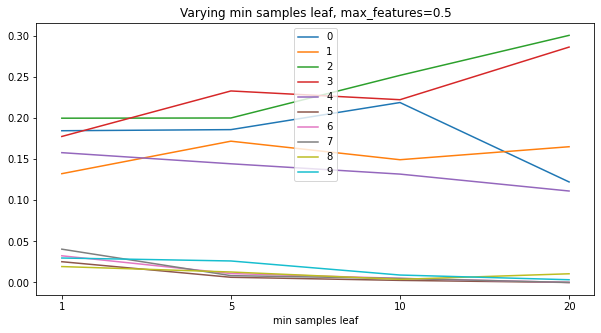

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(FIs_df[FIs_df["max_features"]==0.5].drop(columns=["min_samples_leaf", "max_features"]).reset_index(drop=True), label=np.arange(10))
plt.legend()
plt.xticks(ticks=np.arange(4), labels=min_samples_leaf_grid)
plt.xlabel("min samples leaf")
plt.title("Varying min samples leaf, max_features=0.5")
plt.show()

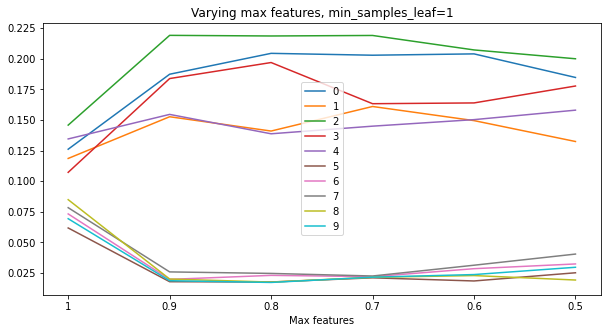

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(FIs_df[FIs_df["min_samples_leaf"]==1].drop(columns=["min_samples_leaf", "max_features"]).reset_index(drop=True), label=np.arange(10))
plt.legend()
plt.xticks(ticks=np.arange(6), labels=mtry_grid)
plt.xlabel("Max features")
plt.title("Varying max features, min_samples_leaf=1")
plt.show()